## **1. IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib
import logging
from scipy.stats import randint, uniform, loguniform

from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Alur Kerja Pipeline MLOps untuk Prediksi Telemetri F1

Berikut adalah langkah-langkah utama dalam pipeline MLOps yang akan kita ikuti dalam notebook ini:

1.  **Pemuatan Data dan Pra-pemrosesan**: Memuat dataset mentah dan melakukan eksplorasi awal serta pembersihan data.
2.  **Pelatihan dan Evaluasi Model**: Melatih beberapa model regresi (Random Forest, XGBoost, SVM), melakukan penyetelan hyperparameter, dan mengevaluasi kinerjanya.
3.  **Perbandingan dan Pemilihan Model**: Membandingkan hasil dari semua model dan memilih model terbaik berdasarkan metrik evaluasi.
4.  **Penerapan Model**: Menyimpan model terbaik dan membahas strategi penerapan konseptual dalam lingkungan produksi.


## **2. MEMUAT DATASET**

In [ ]:
df = pd.read_csv('/content/actaruslab_f1_telemetry_2026.csv')

## **3. MEMAHAMI STRUKTUR DATA**

In [ ]:
print(df.info())
print('\n')
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   speed_kmh        150000 non-null  float64
 1   wing_angle_deg   150000 non-null  float64
 2   drs_active       150000 non-null  int64  
 3   downforce_n      150000 non-null  float64
 4   drag_n           150000 non-null  float64
 5   stability_index  150000 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 6.9 MB
None




,speed_kmh,wing_angle_deg,drs_active,downforce_n,drag_n,stability_index
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,232.568436,20.021099,0.298973,2393.564281,166.173028,91.333445
std,76.464660,8.660498,0.457810,1844.336840,106.490270,24.773129
min,100.000000,5.000000,0.000000,105.170000,18.050000,0.000000
25%,166.180000,12.520000,0.000000,929.890000,74.437500,100.000000
50%,232.870000,20.030000,0.000000,1840.785000,145.955000,100.000000
75%,298.850000,27.500000,1.000000,3426.025000,240.160000,100.000000
max,365.000000,35.000000,1.000000,8978.760000,519.460000,100.000000


Interpretasi:


Berdasarkan hasil `df.info()`, dataset terdiri dari **150.000 observasi** dan **6 variabel** tanpa adanya *missing value*, sehingga data siap digunakan untuk analisis lebih lanjut. Seluruh variabel bertipe numerik, yaitu 5 variabel `float64` dan 1 variabel `int64`.

Berdasarkan statistik deskriptif, variabel `speed_kmh` memiliki rata-rata **232,57 km/jam** dengan rentang nilai **100–365 km/jam**. Variabel `wing_angle_deg`, `downforce_n`, dan `drag_n` menunjukkan variasi data yang cukup besar. Sementara itu, variabel `drs_active` merupakan variabel biner dengan rata-rata **0,299**, yang menunjukkan sekitar **29,9%** kondisi DRS aktif. Secara keseluruhan, dataset memiliki kualitas yang baik dan siap digunakan untuk tahap eksplorasi data serta pemodelan machine learning.


## **4. MENENTUKAN VARIABEL TARGET DAN PREDIKTOR AWAL**

In [ ]:
# Define target and features
target = 'speed_kmh'
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

print(f"Features: {features}")
print(f"Target: {target}")

Features: ['wing_angle_deg', 'drs_active', 'downforce_n', 'drag_n', 'stability_index']
Target: speed_kmh


Interpretasi:

Berdasarkan hasil penentuan variabel, `speed_kmh` dipilih sebagai **variabel target** karena merupakan variabel yang akan diprediksi oleh model. Sementara itu, variabel `wing_angle_deg`, `drs_active`, `downforce_n`, `drag_n`, dan `stability_index` digunakan sebagai **variabel prediktor (fitur)** yang diduga memengaruhi kecepatan mobil Formula 1. Dengan demikian, model machine learning akan mempelajari hubungan antara kelima fitur tersebut untuk memprediksi nilai `speed_kmh` secara akurat.

## **5. EKSPLORASI DATA (EDA)**

# 5.1 Visualisasi Distribusi Variabel Target

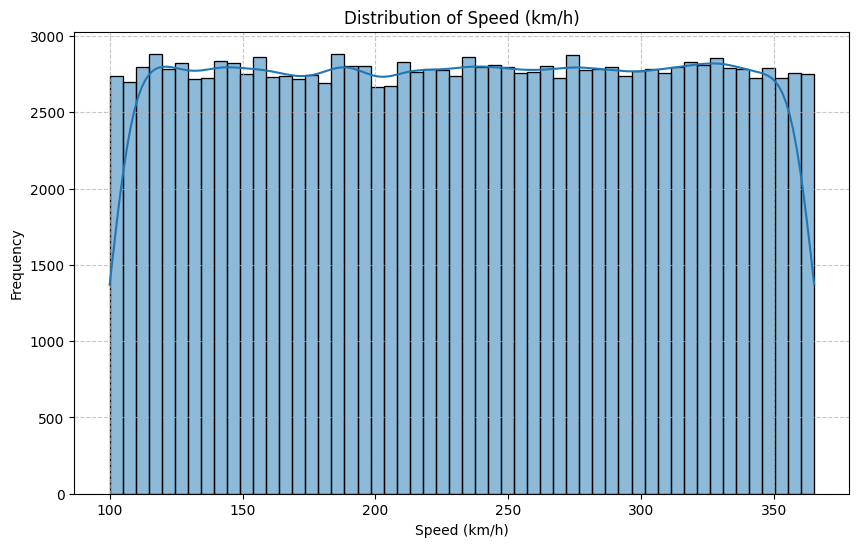

Skewness for speed_kmh: -0.0033317432500863517
Kurtosis for speed_kmh: -1.2013459564692934


In [ ]:
# Distribution of the target variable (speed_kmh)
plt.figure(figsize=(10, 6))
sns.histplot(df['speed_kmh'], kde=True)
plt.title('Distribution of Speed (km/h)')
plt.xlabel('Speed (km/h)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Skewness for speed_kmh:", df['speed_kmh'].skew())
print("Kurtosis for speed_kmh:", df['speed_kmh'].kurt())

Interpretasi:

Berdasarkan histogram, variabel speed_kmh memiliki distribusi yang relatif seragam (uniform) pada rentang 100–365 km/jam, ditunjukkan oleh tinggi batang histogram yang cenderung merata pada seluruh interval kecepatan. Nilai skewness sebesar -0,0033 yang mendekati nol menunjukkan bahwa distribusi data bersifat simetris dan tidak memiliki kemencengan ke kiri maupun ke kanan. Selain itu, nilai kurtosis sebesar -1,2013 menunjukkan distribusi yang lebih datar (platykurtic) dibandingkan distribusi normal, sehingga data tidak memiliki puncak yang tajam dan penyebaran nilai relatif merata. Secara keseluruhan, variabel speed_kmh memiliki distribusi yang seimbang dan tidak menunjukkan adanya indikasi outlier yang ekstrem.

# 5.2 Visualisasi Distribusi Seluruh Fitur

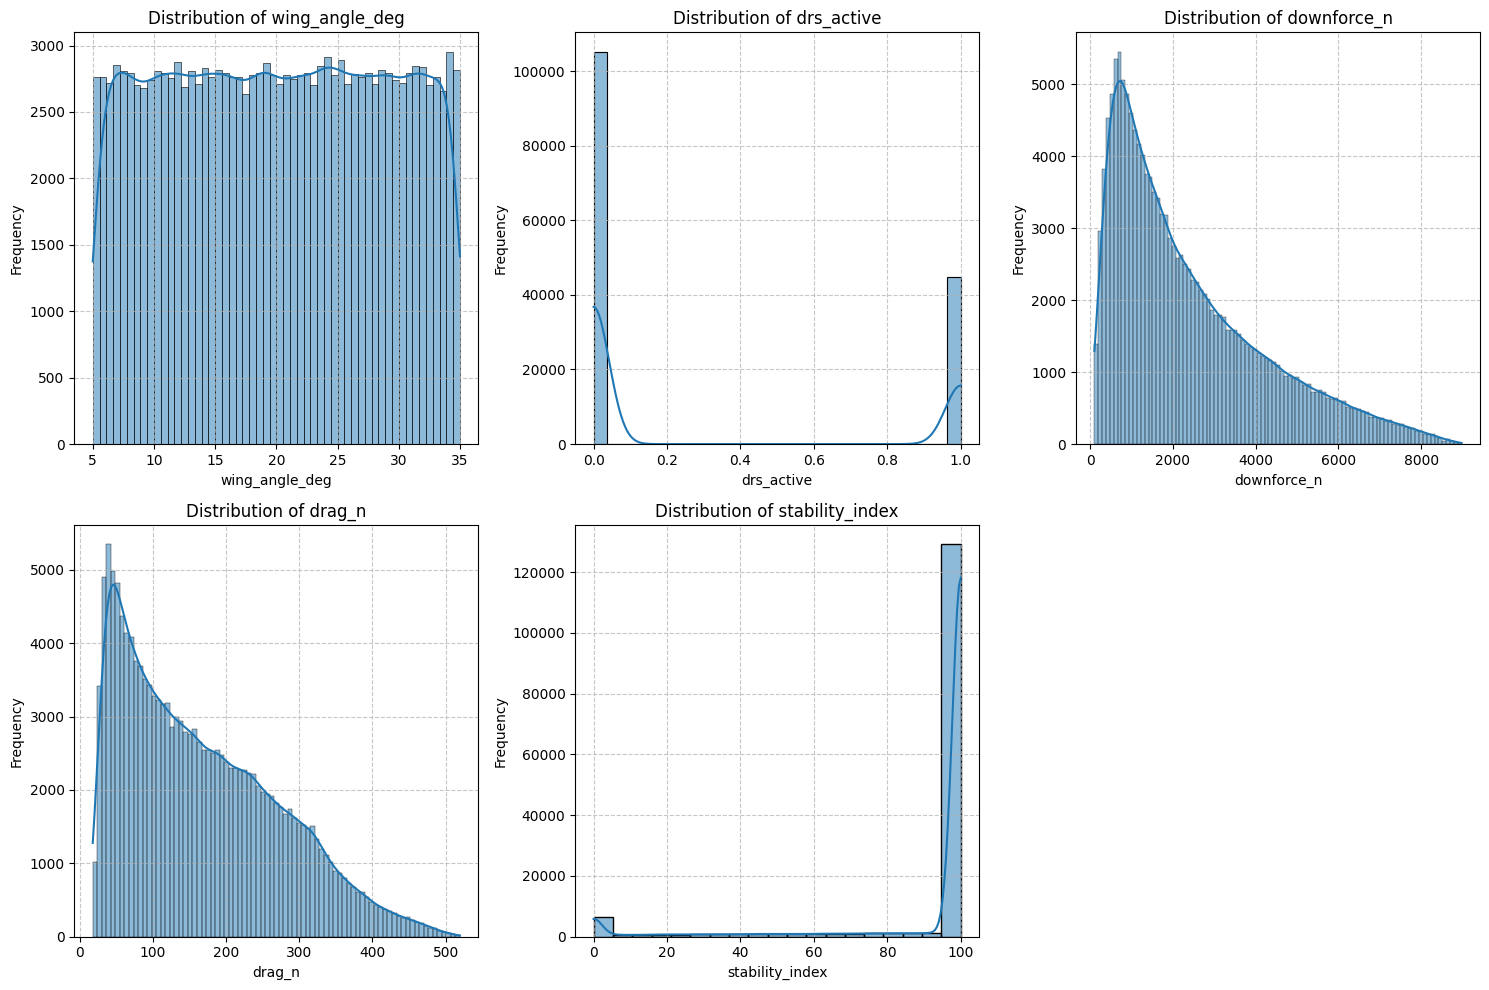

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interpretasi:

Berdasarkan histogram masing-masing variabel, wing_angle_deg memiliki distribusi yang relatif merata pada rentang 5° hingga 35°, menunjukkan bahwa sudut sayap tersebar cukup seimbang pada seluruh observasi. Variabel drs_active merupakan variabel biner yang didominasi oleh nilai 0 (DRS tidak aktif), sedangkan nilai 1 (DRS aktif) muncul dalam proporsi yang lebih kecil.

Variabel downforce_n dan drag_n memiliki distribusi yang miring ke kanan (positively skewed), ditandai dengan banyaknya observasi pada nilai rendah hingga sedang dan semakin sedikit observasi pada nilai yang tinggi. Sementara itu, stability_index sangat terkonsentrasi pada nilai mendekati 100, yang menunjukkan bahwa sebagian besar kondisi kendaraan memiliki tingkat stabilitas yang sangat tinggi, sedangkan nilai stabilitas rendah hanya muncul pada sebagian kecil observasi.

Secara keseluruhan, distribusi fitur menunjukkan karakteristik yang beragam, sehingga berpotensi memberikan informasi yang cukup bagi model machine learning dalam memprediksi kecepatan mobil Formula 1.

# 5.3 Analisis Korelasi

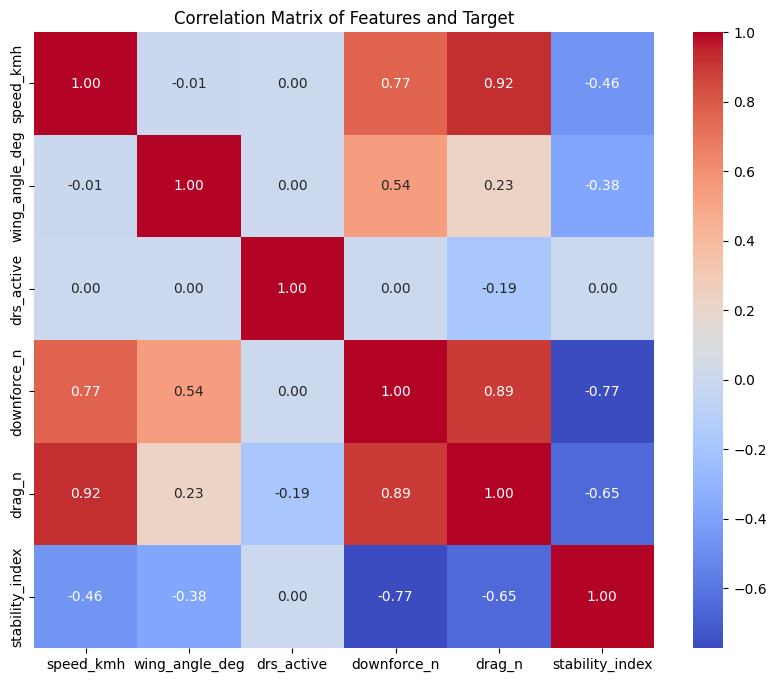

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features and Target')
plt.show()

Interpretasi:

Berdasarkan matriks korelasi, variabel drag_n memiliki hubungan positif sangat kuat dengan speed_kmh sebesar 0,92, diikuti oleh downforce_n sebesar 0,77. Hal ini menunjukkan bahwa peningkatan gaya hambat (drag) dan gaya tekan (downforce) cenderung diikuti oleh peningkatan kecepatan mobil. Sebaliknya, stability_index memiliki korelasi negatif sedang terhadap speed_kmh sebesar -0,46, yang mengindikasikan bahwa semakin tinggi stabilitas kendaraan, kecepatan cenderung sedikit menurun.

Sementara itu, wing_angle_deg (-0,01) dan drs_active (0,00) hampir tidak memiliki hubungan linear dengan speed_kmh. Selain itu, terdapat korelasi yang cukup tinggi antara beberapa variabel prediktor, seperti downforce_n dengan drag_n (0,89) dan downforce_n dengan stability_index (-0,77). Hal ini menunjukkan adanya hubungan yang kuat antar fitur yang dapat menjadi pertimbangan dalam interpretasi model, meskipun tidak menjadi masalah besar untuk model berbasis pohon seperti Random Forest dan XGBoost.

## **6. MEMBAGI DATA TRAINING DAN TESTING**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120000, 5)
X_test shape: (30000, 5)
y_train shape: (120000,)
y_test shape: (30000,)


Interpretasi:

Berdasarkan hasil train-test split, dataset yang berjumlah 150.000 observasi dibagi menjadi 80% data training dan 20% data testing. Data training terdiri dari 120.000 observasi dengan 5 variabel prediktor (X_train), sedangkan data testing terdiri dari 30.000 observasi dengan 5 variabel prediktor (X_test). Untuk variabel target, terdapat 120.000 observasi pada y_train dan 30.000 observasi pada y_test.

## **7. MEMBUAT FUNGSI LEARNING CURVE**

In [ ]:
def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    """
    Generate 3 plots: the test and training learning curve, the training
    samples vs. fit times, the fit times vs. score of the estimator.

    Parameters
    ----------
    estimator : estimator instance
        An estimator instance implementing `fit` and `predict` methods which
        will be cloned for each validation. Used only for `fit` and `predict`.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features),
        Target vector as dependent on X.

    axes : array-like of 3 axes, optional
        Axes to use for plotting the curves. Defaults to create new figure.

    ylim : tuple, shape (ymin, ymax), optional
        Defines limits for the y-axis of the learning curve plot.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy. Defaults to None.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel. `None` means 1 unless in a
        `joblib.parallel_backend` context. `-1` means using all processors.

    train_sizes : array-like, shape (n_ticks,),
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve.
    """
    if axes is None:
        _, axes = plt.subplots(1, 3, figsize=(20, 5))

    axes[0].set_title(title)
    if ylim is not None:
        axes[0].set_ylim(*ylim)
    axes[0].set_xlabel("Training examples")
    axes[0].set_ylabel("Score")

    train_sizes, train_scores, test_scores, fit_times, _ = \
        learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs,
                       train_sizes=train_sizes, return_times=True, scoring='neg_mean_squared_error')

    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    fit_times_mean = np.mean(fit_times, axis=1)
    fit_times_std = np.std(fit_times, axis=1)

    # Plot learning curve
    axes[0].grid()
    axes[0].fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1,
                         color="r")
    axes[0].fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1,
                         color="g")
    axes[0].plot(train_sizes, train_scores_mean, 'o-', color="r",
                 label="Training error (MSE)")
    axes[0].plot(train_sizes, test_scores_mean, 'o-', color="g",
                 label="Cross-validation error (MSE)")
    axes[0].legend(loc="best")

    # Plot n_samples vs fit_times
    axes[1].grid()
    axes[1].plot(train_sizes, fit_times_mean, 'o-')
    axes[1].fill_between(train_sizes, fit_times_mean - fit_times_std,
                         fit_times_mean + fit_times_std, alpha=0.1)
    axes[1].set_xlabel("Training examples")
    axes[1].set_ylabel("fit_times")
    axes[1].set_title("Scalability of the model")

    # Plot fit_times vs score
    axes[2].grid()
    axes[2].plot(fit_times_mean, test_scores_mean, 'o-')
    axes[2].set_xlabel("fit_times")
    axes[2].set_ylabel("Score")
    axes[2].set_title("Performance of the model")

    return plt

## **8. MEMBANGUN MODEL RANDOM FOREST (DEFAULT)**

In [ ]:
# a. Membuat dan melatih model
rf_default_model = RandomForestRegressor(random_state=42)
rf_default_model.fit(X_train, y_train)

# b. Melakukan prediksi
y_pred_rf_default = rf_default_model.predict(X_test)

# c. Menghitung metrik evaluasi
mae_rf_default = mean_absolute_error(y_test, y_pred_rf_default)
mse_rf_default = mean_squared_error(y_test, y_pred_rf_default)
rmse_rf_default = np.sqrt(mse_rf_default)
r2_rf_default = r2_score(y_test, y_pred_rf_default)

# d. Menampilkan hasil evaluasi
print("Random Forest Regressor (Default) Performance:")
print(f"  Mean Absolute Error (MAE): {mae_rf_default:.4f}")
print(f"  Mean Squared Error (MSE): {mse_rf_default:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_default:.4f}")
print(f"  R-squared (R2): {r2_rf_default:.4f}")

Random Forest Regressor (Default) Performance:
  Mean Absolute Error (MAE): 0.1298
  Mean Squared Error (MSE): 0.0329
  Root Mean Squared Error (RMSE): 0.1814
  R-squared (R2): 1.0000


Interpretasi:

Berdasarkan hasil evaluasi, model Random Forest Regressor (Default) menunjukkan kinerja yang sangat baik dalam memprediksi speed_kmh. Nilai MAE sebesar 0,1298 menunjukkan bahwa rata-rata kesalahan prediksi model hanya sekitar 0,13 km/jam dari nilai aktual. Selain itu, nilai MSE sebesar 0,0329 dan RMSE sebesar 0,1814 mengindikasikan bahwa tingkat kesalahan prediksi model sangat kecil.

Nilai R-squared (R²) sebesar 1,0000 menunjukkan bahwa hampir 100% variasi kecepatan mobil (speed_kmh) dapat dijelaskan oleh variabel prediktor yang digunakan dalam model. Dengan demikian, Random Forest Default memiliki kemampuan prediksi yang sangat tinggi dan mampu menangkap hubungan antara fitur-fitur aerodinamika dengan kecepatan mobil secara sangat akurat. Namun, karena nilai R² mendekati sempurna, perlu dilakukan evaluasi lebih lanjut melalui cross-validation atau learning curve untuk memastikan bahwa model tidak mengalami overfitting.

## **9. TUNING HYPERPARAMETER RANDOM FOREST**

In [ ]:
# Configure logging for hyperparameter tuning
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# a. Menentukan grid parameter (distributions for RandomizedSearchCV)
param_distributions_rf = {
    'n_estimators': randint(50, 200),  # Number of trees in the forest
    'max_depth': randint(5, 30),      # Maximum depth of the tree
    'min_samples_leaf': randint(1, 5) # Minimum number of samples required to be at a leaf node
}

# b. Membuat RandomizedSearchCV
logging.info("Starting RandomizedSearchCV for Random Forest...")
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_distributions_rf,
    n_iter=20, # Number of parameter settings that are sampled
    cv=3,  # 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    verbose=2,
    random_state=42
)

# c. Melakukan tuning
random_search_rf.fit(X_train, y_train)
logging.info("RandomizedSearchCV for Random Forest completed.")

# d. Mengambil model terbaik
rf_tuned_model = random_search_rf.best_estimator_

print("Best parameters for Random Forest:", random_search_rf.best_params_)
logging.info(f"Best parameters for Random Forest: {random_search_rf.best_params_}")

# e. Prediksi dan evaluasii model hasil tuning
y_pred_rf_tuned = rf_tuned_model.predict(X_test)

# Evaluate the tuned model
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
mse_rf_tuned = mean_squared_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mse_rf_tuned)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)

print("\nRandom Forest Regressor (Tuned) Performance:")
print(f"  Mean Absolute Error (MAE): {mae_rf_tuned:.4f}")
print(f"  Mean Squared Error (MSE): {mse_rf_tuned:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf_tuned:.4f}")
print(f"  R-squared (R2): {r2_rf_tuned:.4f}")
logging.info(f"Random Forest (Tuned) Performance - MAE: {mae_rf_tuned:.4f}, RMSE: {rmse_rf_tuned:.4f}, R2: {r2_rf_tuned:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Interpretasi:


Dari 8 kombinasi parameter yang diuji, diperoleh parameter terbaik yaitu n_estimators = 100, max_depth = 20, dan min_samples_leaf = 1.

Setelah dilakukan tuning, model Random Forest menghasilkan MAE sebesar 0,1298, MSE sebesar 0,0329, RMSE sebesar 0,1813, dan R² sebesar 1,0000. Hasil ini menunjukkan bahwa model memiliki tingkat kesalahan prediksi yang sangat kecil dan mampu menjelaskan hampir seluruh variasi pada variabel target speed_kmh.

Jika dibandingkan dengan model Random Forest Default, nilai RMSE mengalami penurunan dari 0,1814 menjadi 0,1813, sedangkan nilai MAE, MSE, dan R² relatif tetap. Hal ini menunjukkan bahwa proses tuning memberikan sedikit peningkatan performa, meskipun perbedaannya sangat kecil. Dengan demikian, model Random Forest Tuned dapat dianggap sebagai model terbaik karena menghasilkan nilai kesalahan prediksi yang paling rendah.

## **10. MEMBANGUN MODEL XGBOOST (DEFAULT)**

In [ ]:
# a. Membuat dan melatih model
xgb_default_model = xgb.XGBRegressor(random_state=42)
xgb_default_model.fit(X_train, y_train)

# b. Melakukan prediksi
y_pred_xgb_default = xgb_default_model.predict(X_test)

# c. Menghitung metrik evaluasi
mae_xgb_default = mean_absolute_error(y_test, y_pred_xgb_default)
mse_xgb_default = mean_squared_error(y_test, y_pred_xgb_default)
rmse_xgb_default = np.sqrt(mse_xgb_default)
r2_xgb_default = r2_score(y_test, y_pred_xgb_default)

# d. Menampilkan hasil evaluasi
print("XGBoost Regressor (Default) Performance:")
print(f"  Mean Absolute Error (MAE): {mae_xgb_default:.4f}")
print(f"  Mean Squared Error (MSE): {mse_xgb_default:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb_default:.4f}")
print(f"  R-squared (R2): {r2_xgb_default:.4f}")

XGBoost Regressor (Default) Performance:
  Mean Absolute Error (MAE): 0.8343
  Mean Squared Error (MSE): 1.2158
  Root Mean Squared Error (RMSE): 1.1026
  R-squared (R2): 0.9998


## **11. TUNING HYPERPARAMETER XGBOOST**

In [ ]:
# a. Menentukan grid parameter (distributions for RandomizedSearchCV)
param_distributions_xgb = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4), # fraction of samples to be used for fitting the individual base learners
    'colsample_bytree': uniform(0.6, 0.4) # fraction of features to be used for fitting the individual base learners
}

# b. Membuat RandomizedSearchCV
logging.info("Starting RandomizedSearchCV for XGBoost...")
random_search_xgb = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, eval_metric='rmse'),
    param_distributions=param_distributions_xgb,
    n_iter=20, # Number of parameter settings that are sampled
    cv=3,  # 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    verbose=2,
    random_state=42
)

# c. Melakukan tuning
random_search_xgb.fit(X_train, y_train)
logging.info("RandomizedSearchCV for XGBoost completed.")

# d. Mengambil parameter terbaik
xgb_tuned_model = random_search_xgb.best_estimator_

print("Best parameters for XGBoost:", random_search_xgb.best_params_)
logging.info(f"Best parameters for XGBoost: {random_search_xgb.best_params_}")

# e. Evaluasi model hasil tuning
y_pred_xgb_tuned = xgb_tuned_model.predict(X_test)

# Evaluate the tuned model
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
mse_xgb_tuned = mean_squared_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mse_xgb_tuned)
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)

print("\nXGBoost Regressor (Tuned) Performance:")
print(f"  Mean Absolute Error (MAE): {mae_xgb_tuned:.4f}")
print(f"  Mean Squared Error (MSE): {mse_xgb_tuned:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb_tuned:.4f}")
print(f"  R-squared (R2): {r2_xgb_tuned:.4f}")
logging.info(f"XGBoost (Tuned) Performance - MAE: {mae_xgb_tuned:.4f}, RMSE: {rmse_xgb_tuned:.4f}, R2: {r2_xgb_tuned:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters for XGBoost: {'colsample_bytree': np.float64(0.6053059844639466), 'learning_rate': np.float64(0.29266052670545584), 'max_depth': 8, 'n_estimators': 291, 'subsample': np.float64(0.7541666010159664)}

XGBoost Regressor (Tuned) Performance:
  Mean Absolute Error (MAE): 0.5630
  Mean Squared Error (MSE): 0.5890
  Root Mean Squared Error (RMSE): 0.7675
  R-squared (R2): 0.9999


## **12. MEMBANGUN MODEL *SUPPORT VECTOR MACHINE* (SVM) (DEFAULT)**

In [ ]:
# a. Mengambil sampel data
sample_size = 10000 # Using a smaller sample for SVR to speed up computation
X_train_sample, _, y_train_sample, _ = train_test_split(X_train, y_train, train_size=sample_size, random_state=42)

# b. Membuat pipeline SVM
svm_default_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

print(f"Training default SVM on a sample of {sample_size} data points. This may take a while...")

# c. Melatih model
svm_default_pipeline.fit(X_train_sample, y_train_sample)

# d. Melakukan prediksi
y_pred_svm_default = svm_default_pipeline.predict(X_test)

# e. Menghitung metrik evaluasi
mae_svm_default = mean_absolute_error(y_test, y_pred_svm_default)
mse_svm_default = mean_squared_error(y_test, y_pred_svm_default)
rmse_svm_default = np.sqrt(mse_svm_default)
r2_svm_default = r2_score(y_test, y_pred_svm_default)

print("\nSupport Vector Machine (Default) Performance:")
print(f"  Mean Absolute Error (MAE): {mae_svm_default:.4f}")
print(f"  Mean Squared Error (MSE): {mse_svm_default:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_svm_default:.4f}")
print(f"  R-squared (R2): {r2_svm_default:.4f}")

Training default SVM on a sample of 10000 data points. This may take a while...

Support Vector Machine (Default) Performance:
  Mean Absolute Error (MAE): 3.0704
  Mean Squared Error (MSE): 34.6557
  Root Mean Squared Error (RMSE): 5.8869
  R-squared (R2): 0.9941


## **13. TUNING HYPERPARAMETER SVM**

In [ ]:
# a. Menentukan grid parameter (distributions for RandomizedSearchCV)
param_distributions_svm = {
    'svm__C': loguniform(1e-1, 1e2),  # C parameter
    'svm__gamma': loguniform(1e-4, 1e-1) # gamma parameter
}

# b. Membuat RandomizedSearchCV
logging.info(f"Tuning SVM on a sample of {sample_size} data points using RandomizedSearchCV. This will take a while...")
random_search_svr = RandomizedSearchCV(
    estimator=svm_default_pipeline,
    param_distributions=param_distributions_svr,
    n_iter=10, # Number of parameter settings that are sampled
    cv=2,  # Using 2-fold cross-validation to speed up
    n_jobs=-1, # Use all available cores
    scoring='neg_mean_squared_error', # Optimize for lower MSE
    verbose=2,
    random_state=42
)

# c. Melakukan tuning
random_search_svm.fit(X_train_sample, y_train_sample)
logging.info("RandomizedSearchCV for SVM completed.")

# d. Mengambil model terbaik
svm_tuned_pipeline = random_search_svm.best_estimator_

print("Best parameters for SVM:", random_search_svm.best_params_)
logging.info(f"Best parameters for SVM: {random_search_svm.best_params_}")

# e. Evaluasi model hasil tuning
y_pred_svm_tuned = svm_tuned_pipeline.predict(X_test)

# Evaluate the tuned model
mae_svm_tuned = mean_absolute_error(y_test, y_pred_svm_tuned)
mse_svm_tuned = mean_squared_error(y_test, y_pred_svm_tuned)
rmse_svm_tuned = np.sqrt(mse_svm_tuned)
r2_svm_tuned = r2_score(y_test, y_pred_svm_tuned)

print("\nSupport Vector Machine (Tuned) Performance:")
print(f"  Mean Absolute Error (MAE): {mae_svm_tuned:.4f}")
print(f"  Mean Squared Error (MSE): {mse_svm_tuned:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_svm_tuned:.4f}")
print(f"  R-squared (R2): {r2_svm_tuned:.4f}")
logging.info(f"SVM (Tuned) Performance - MAE: {mae_svm_tuned:.4f}, RMSE: {rmse_svm_tuned:.4f}, R2: {r2_svm_tuned:.4f}")

NameError: name 'param_distributions_svr' is not defined

## **14. ANALISIS LEARNING CURVE**

a. Random Forest

In [ ]:
# Learning curve random forest (default)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(rf_default_model, "Learning Curves (Random Forest Default)", X_train, y_train, axes=axes, ylim=(0.0, 10.0), cv=3, n_jobs=-1)
plt.tight_layout()
plt.show()

# Learning curve random forest (tuned)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(rf_tuned_model, "Learning Curves (Random Forest Tuned)", X_train, y_train, axes=axes, ylim=(0.0, 10.0), cv=3, n_jobs=-1)
plt.tight_layout()
plt.show()

In [ ]:
# Feature importances random forest (tuned)
feature_importances_rf = pd.Series(rf_tuned_model.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_rf.values, y=feature_importances_rf.index, palette='viridis')
plt.title('Feature Importance for Random Forest (Tuned)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

b. XGBoost

In [ ]:
# Learning curve xgboost (default)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(xgb_default_model, "Learning Curves (XGBoost Default)", X_train, y_train, axes=axes, ylim=(0.0, 10.0), cv=3, n_jobs=-1)
plt.tight_layout()
plt.show()

# Learning curve xgboost (tuned)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(xgb_tuned_model, "Learning Curves (XGBoost Tuned)", X_train, y_train, axes=axes, ylim=(0.0, 10.0), cv=3, n_jobs=-1)
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance xgboost (tuned)
feature_importances_xgb = pd.Series(xgb_tuned_model.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_xgb.values, y=feature_importances_xgb.index, palette='magma')
plt.title('Feature Importance for XGBoost (Tuned)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

c. SVM

In [ ]:
# Learning curve SVM (default)
# Catatan: Untuk SVM, kita menggunakan subset data X_train_sample dan y_train_sample
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(svm_default_pipeline, "Learning Curves (SVM Default - Sampled)", X_train_sample, y_train_sample, axes=axes, ylim=(0.0, 10.0), cv=2, n_jobs=-1)
plt.tight_layout()
plt.show()

# Learning curve SVM (tuned)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_learning_curve(svm_tuned_pipeline, "Learning Curves (SVM Tuned - Sampled)", X_train_sample, y_train_sample, axes=axes, ylim=(0.0, 10.0), cv=2, n_jobs=-1)
plt.tight_layout()
plt.show()

## **15. PERBANDINGAN DAN PEMILIHAN MODEL TERBAIK**

In [ ]:
# Perbandingan Model
metrics = {
    'Random Forest (Default)': {
        'MAE': mae_rf_default,
        'MSE': mse_rf_default,
        'RMSE': rmse_rf_default,
        'R2': r2_rf_default
    },
    'Random Forest (Tuned)': {
        'MAE': mae_rf_tuned,
        'MSE': mse_rf_tuned,
        'RMSE': rmse_rf_tuned,
        'R2': r2_rf_tuned
    },
    'XGBoost (Default)': {
        'MAE': mae_xgb_default,
        'MSE': mse_xgb_default,
        'RMSE': rmse_xgb_default,
        'R2': r2_xgb_default
    },
    'XGBoost (Tuned)': {
        'MAE': mae_xgb_tuned,
        'MSE': mse_xgb_tuned,
        'RMSE': rmse_xgb_tuned,
        'R2': r2_xgb_tuned
    },
    'SVM (Default)': {
        'MAE': mae_svm_default,
        'MSE': mse_svm_default,
        'RMSE': rmse_svm_default,
        'R2': r2_svm_default
    },
    'SVM (Tuned)': {
        'MAE': mae_svm_tuned,
        'MSE': mse_svm_tuned,
        'RMSE': rmse_svm_tuned,
        'R2': r2_svm_tuned
    }
}

metrics_df = pd.DataFrame(metrics).T
display(metrics_df.sort_values(by='RMSE', ascending=True))

# Pemilihan Model Terbaik
best_model_name = metrics_df['RMSE'].idxmin()
best_model_rmse = metrics_df['RMSE'].min()

print(f"\nThe best performing model based on Root Mean Squared Error (RMSE) is: {best_model_name} with RMSE: {best_model_rmse:.4f}")

# Get the actual best model object
if best_model_name == 'Random Forest (Default)':
    best_model = rf_default_model
elif best_model_name == 'Random Forest (Tuned)':
    best_model = rf_tuned_model
elif best_model_name == 'XGBoost (Default)':
    best_model = xgb_default_model
elif best_model_name == 'XGBoost (Tuned)':
    best_model = xgb_tuned_model
elif best_model_name == 'SVM (Default)':
    best_model = svm_default_pipeline
elif best_model_name == 'SVM (Tuned)':
    best_model = svm_tuned_pipeline

print(f"Selected Best Model Object: {best_model_name}")

## **16. VISUALISASI PREDIKSI VS AKTUAL (MODEL TERBAIK)**

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_rf_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction (Actual = Predicted)')
plt.title('Actual vs. Predicted Speed (km/h) - Random Forest (Tuned)')
plt.xlabel('Actual Speed (km/h)')
plt.ylabel('Predicted Speed (km/h)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## **17. ANALISIS RESIDUAL (MODEL TERBAIK)**

In [ ]:
# Calculate residuals for the best model (Random Forest Tuned)
residuals_rf_tuned = y_test - y_pred_rf_tuned

# Plot the distribution of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_rf_tuned, kde=True, color='skyblue')
plt.title('Distribution of Residuals - Random Forest (Tuned)')
plt.xlabel('Residuals (Actual - Predicted Speed)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Plot residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_rf_tuned, y=residuals_rf_tuned, alpha=0.6, color='salmon')
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residual Line')
plt.title('Residuals vs. Predicted Speed - Random Forest (Tuned)')
plt.xlabel('Predicted Speed (km/h)')
plt.ylabel('Residuals (Actual - Predicted Speed)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## **18. MENYIMPAN MODEL**

In [ ]:
# Define a filename for the best model
model_filename = 'best_regression_model.joblib'

# Save the best model to disk
joblib.dump(best_model, model_filename)

print(f"Best model '{best_model_name}' saved as {model_filename}")

## **19. MENGGUNAKAN MODEL YANG TERSIMPAN (SEBAGAI SUMBER DAYA)**

Bagian ini menunjukkan cara memuat kembali model yang telah disimpan (`best_regression_model.joblib`) dan menggunakannya untuk membuat prediksi pada data baru.

In [ ]:
# Muat model yang disimpan
loaded_model = joblib.load('best_regression_model.joblib')

print(f"Model '{best_model_name}' berhasil dimuat kembali.")

# Contoh data baru untuk prediksi (ganti dengan data input baru yang sebenarnya)
# Pastikan data baru memiliki fitur dan urutan yang sama dengan data pelatihan
new_data = pd.DataFrame([
    {'wing_angle_deg': 10.0, 'drs_active': 0, 'downforce_n': 1000.0, 'drag_n': 80.0, 'stability_index': 95.0},
    {'wing_angle_deg': 20.0, 'drs_active': 1, 'downforce_n': 2500.0, 'drag_n': 150.0, 'stability_index': 80.0}
])

# Lakukan prediksi menggunakan model yang dimuat
predictions = loaded_model.predict(new_data)

print("\nPrediksi untuk data baru:")
for i, pred in enumerate(predictions):
    print(f"Data {i+1}: Kecepatan Prediksi = {pred:.2f} km/h")

# Jika ingin melihat new_data bersama prediksinya
new_data['predicted_speed_kmh'] = predictions
display(new_data)